In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_copy = train.copy(deep=True)
test_copy = test.copy(deep=True)
data = [train_copy,test_copy]

In [5]:
m_or_f_count_1 = train[train.Survived==1]
lived = m_or_f_count_1[['Sex','Survived']].groupby(['Sex']).count().reset_index()
lived

,Sex,Survived
0,female,233
1,male,109


In [6]:
train.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [7]:
train[['Parch','Survived']].groupby(['Parch']).mean().sort_values('Survived',ascending=False).reset_index()

,Parch,Survived
0,3,0.600000
1,1,0.550847
2,2,0.500000
3,0,0.343658
4,5,0.200000
5,4,0.000000
6,6,0.000000


In [8]:
train[['SibSp','Survived']].groupby(['SibSp']).mean().sort_values('Survived',ascending=False).reset_index()

,SibSp,Survived
0,1,0.535885
1,2,0.464286
2,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [9]:
train[['Pclass','Survived']].groupby(['Pclass']).mean().reset_index()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


class 1 survive most where class 3 survive less

In [10]:
train[['Age','Survived']].groupby(['Age']).count().sort_values('Survived',ascending=False).reset_index()

,Age,Survived
0,24.00,30
1,22.00,27
2,18.00,26
3,30.00,25
4,28.00,25
...,...,...
83,20.50,1
84,14.50,1
85,12.00,1
86,0.92,1


In [11]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

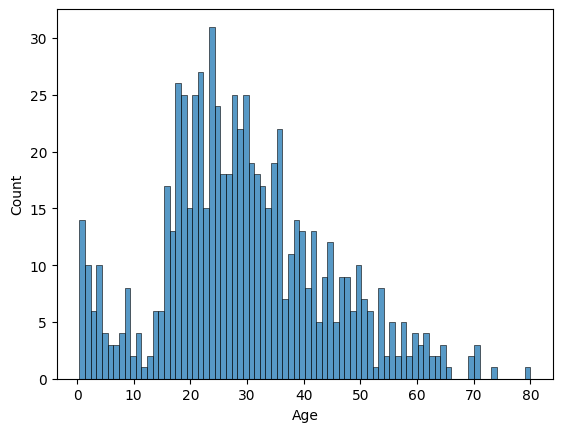

In [13]:
sns.histplot(train.Age,bins=80)
plt.show()

In [14]:
import warnings
warnings.filterwarnings("ignore")


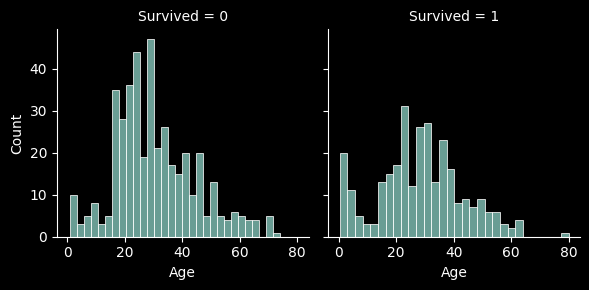

In [15]:
plt.style.use('dark_background')

survived_age = sns.FacetGrid(train,col='Survived')
survived_age.map(sns.histplot,'Age',bins=30)
plt.show()

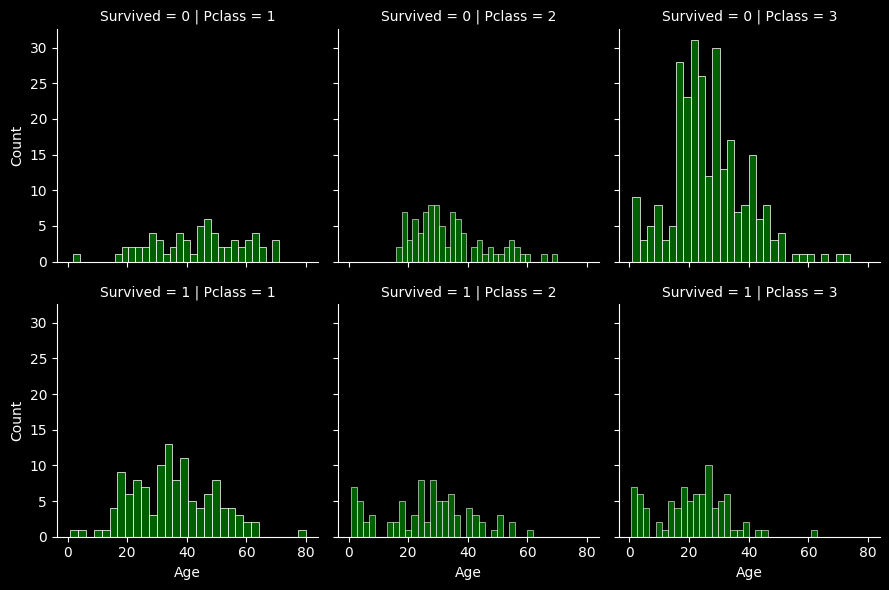

In [16]:
pclass_survived_age = sns.FacetGrid(train,col='Pclass',row='Survived')
pclass_survived_age.map(sns.histplot,'Age',bins=30,color='green')
plt.show()

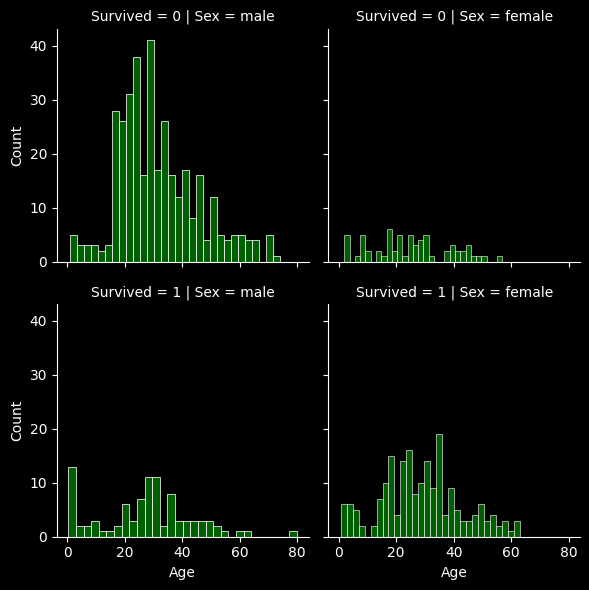

In [17]:
pclass_survived_age = sns.FacetGrid(train,col='Sex',row='Survived')
pclass_survived_age.map(sns.histplot,'Age',bins=30,color='green')
plt.show()

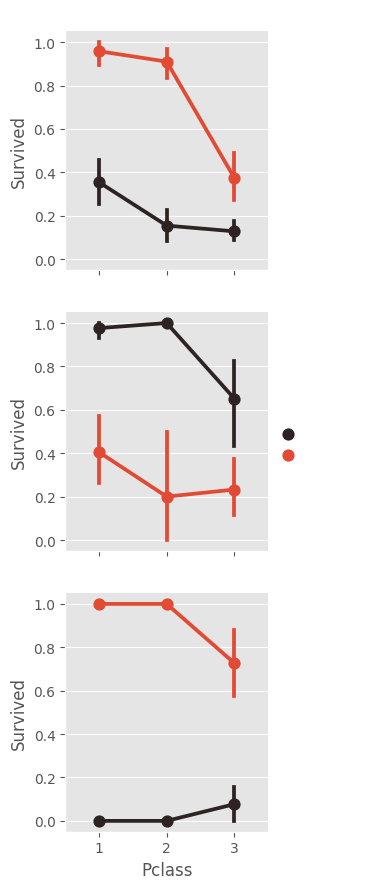

In [18]:
plt.style.use('ggplot')
Pc_Age_Sx = sns.FacetGrid(train,row='Embarked')
Pc_Age_Sx.map(sns.pointplot,'Pclass','Survived','Sex')
Pc_Age_Sx.add_legend()
plt.show()

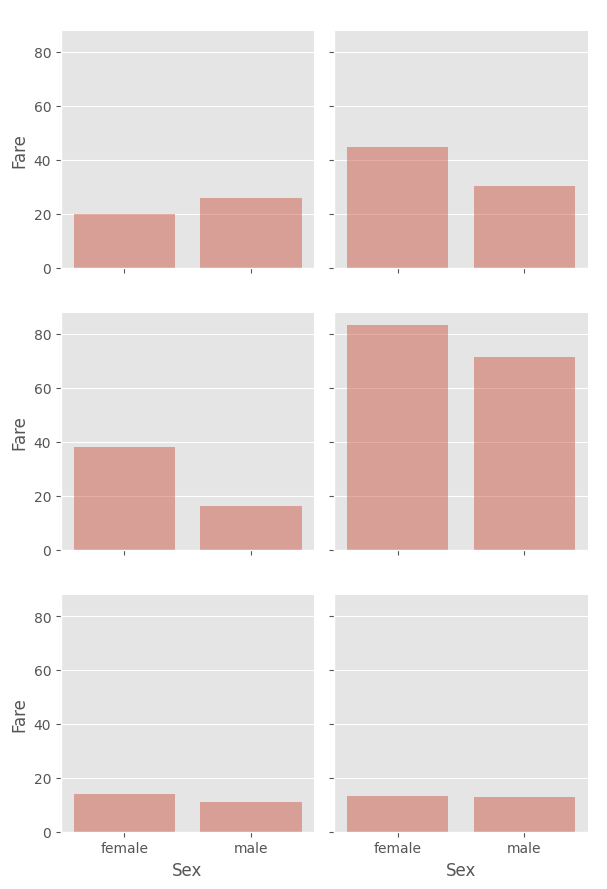

In [19]:
grid = sns.FacetGrid(train, row='Embarked', col='Survived')
grid.map(sns.barplot, 'Sex', 'Fare', alpha=.5, ci=None)
grid.add_legend()

In [20]:
train = train.drop(['Ticket','Cabin'],axis=1)
test = test.drop(['Ticket','Cabin'],axis=1)

In [21]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S


In [22]:
combine = [train,test]

In [23]:
train['Family_Size'] = train['SibSp'] + train['Parch'] +1
test['Family_Size'] = test['SibSp'] + test['Parch']+1 

In [24]:
train = train.drop(['SibSp','Parch'],axis=1)
test = test.drop(['SibSp','Parch'],axis=1)

In [25]:
train['Is_Alone'] = train['Family_Size'].apply(lambda x: 1 if x==1 else 0)

In [26]:
test['Is_Alone'] = test['Family_Size'].apply(lambda x: 1 if x==1 else 0)

In [27]:
# train = train.drop(['Family_Size'],axis=1)
# test = test.drop(['Family_Size'],axis=1)

In [28]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Family_Size,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S,1,1


In [29]:
for dataset in combine:
    dataset.Sex = dataset.Sex.apply(lambda x: 1 if x=='male' else 0 )

In [30]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Family_Size,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S,1,1


In [31]:
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Family_Size,Is_Alone
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,889,891.000000,891.000000
unique,NaN,NaN,NaN,891,2,NaN,NaN,3,NaN,NaN
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,S,NaN,NaN
freq,NaN,NaN,NaN,1,577,NaN,NaN,644,NaN,NaN
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,32.204208,NaN,1.904602,0.602694
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,49.693429,NaN,1.613459,0.489615
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,NaN,1.000000,0.000000
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,7.910400,NaN,1.000000,0.000000
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,14.454200,NaN,1.000000,1.000000
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,31.000000,NaN,2.000000,1.000000


In [32]:
dataset

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Size
0,892,3,"Kelly, Mr. James",1,34.5,0,0,7.8292,Q,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",0,47.0,1,0,7.0000,S,2
2,894,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,9.6875,Q,1
3,895,3,"Wirz, Mr. Albert",1,27.0,0,0,8.6625,S,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,12.2875,S,3
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",1,NaN,0,0,8.0500,S,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",0,39.0,0,0,108.9000,C,1
415,1307,3,"Saether, Mr. Simon Sivertsen",1,38.5,0,0,7.2500,S,1
416,1308,3,"Ware, Mr. Frederick",1,NaN,0,0,8.0500,S,1


In [33]:
train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,Fare,Family_Size,Is_Alone
PassengerId,1.000000,-0.005007,-0.035144,0.036847,0.012658,-0.040143,0.057462
Survived,-0.005007,1.000000,-0.338481,-0.077221,0.257307,0.016639,-0.203367
Pclass,-0.035144,-0.338481,1.000000,-0.369226,-0.549500,0.065997,0.135207
Age,0.036847,-0.077221,-0.369226,1.000000,0.096067,-0.301914,0.198270
Fare,0.012658,0.257307,-0.549500,0.096067,1.000000,0.217138,-0.271832
Family_Size,-0.040143,0.016639,0.065997,-0.301914,0.217138,1.000000,-0.690922
Is_Alone,0.057462,-0.203367,0.135207,0.198270,-0.271832,-0.690922,1.000000


In [34]:
train[['Pclass','Survived']].groupby(['Pclass']).mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [35]:
train[['Sex','Survived']].groupby(['Sex']).mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [36]:
train[['Is_Alone','Survived']].groupby(['Is_Alone']).mean()

,Survived
Is_Alone,
0,0.505650
1,0.303538


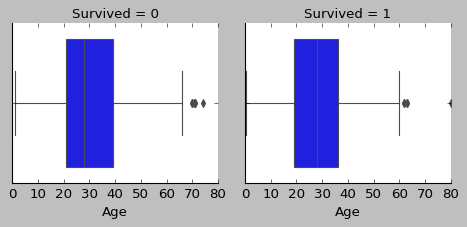

In [37]:
plt.style.use('classic')
survived_age = sns.FacetGrid(train,col='Survived')
survived_age.map(sns.boxplot,'Age')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

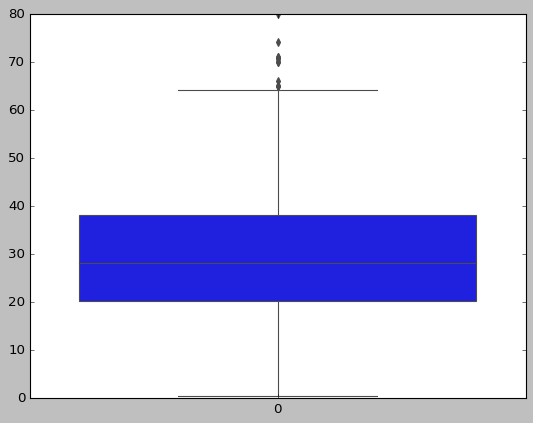

In [38]:
sns.boxplot(train.Age)
plt.show

<Axes: xlabel='Age', ylabel='Density'>

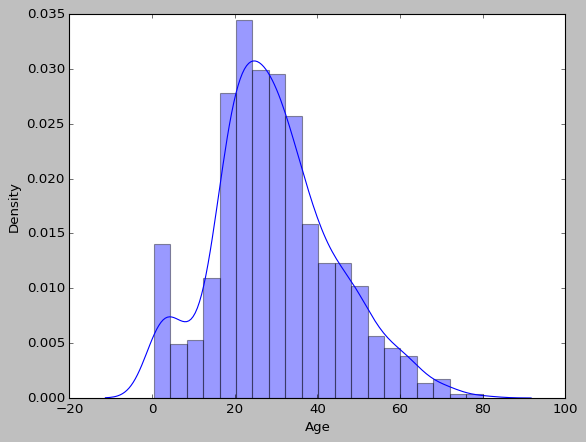

In [39]:
sns.distplot(train.Age)



In [40]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Family_Size,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S,1,1


In [41]:
num_train = train.select_dtypes(exclude='object').copy()

In [42]:
num_train.head()

,PassengerId,Survived,Pclass,Age,Fare,Family_Size,Is_Alone
0,1,0,3,22.0,7.2500,2,0
1,2,1,1,38.0,71.2833,2,0
2,3,1,3,26.0,7.9250,1,1
3,4,1,1,35.0,53.1000,2,0
4,5,0,3,35.0,8.0500,1,1


In [43]:
num_train.corr()

,PassengerId,Survived,Pclass,Age,Fare,Family_Size,Is_Alone
PassengerId,1.000000,-0.005007,-0.035144,0.036847,0.012658,-0.040143,0.057462
Survived,-0.005007,1.000000,-0.338481,-0.077221,0.257307,0.016639,-0.203367
Pclass,-0.035144,-0.338481,1.000000,-0.369226,-0.549500,0.065997,0.135207
Age,0.036847,-0.077221,-0.369226,1.000000,0.096067,-0.301914,0.198270
Fare,0.012658,0.257307,-0.549500,0.096067,1.000000,0.217138,-0.271832
Family_Size,-0.040143,0.016639,0.065997,-0.301914,0.217138,1.000000,-0.690922
Is_Alone,0.057462,-0.203367,0.135207,0.198270,-0.271832,-0.690922,1.000000


<Axes: >

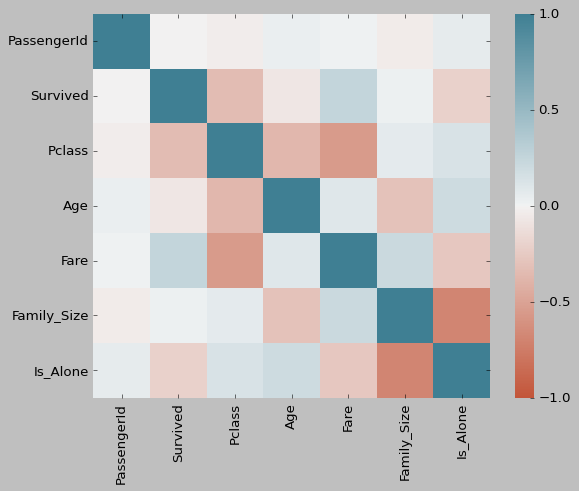

In [44]:
sns.heatmap(num_train.corr(),vmax=1,vmin=-1,cmap=sns.diverging_palette(20, 220, as_cmap=True),robust=True)

In [45]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Family_Size,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S,1,1


In [49]:
import tensorflow as tf

In [ ]:
layer = tf.keras.layers.Normalization(axis=None)
layer.adapt(adapt_data)
